# Düzenlileştirme

**Titanic** yolcularının hayatta kalma şansını etkileyen faktörlere dair anlayışımızı geliştirelim
- Yorumlaması kolay olan lojistik sınıflandırıcıları kullanacağız
- Bunu daha önce "Karar Bilimi - Lojistik Regresyon" dersinde statsmodels ile yapmıştık
- Hangi özelliklerin alakasız olduğunu / genelleştirilemediğini tespit etmek için `p-değerleri` ve istatistiksel varsayımlar kullanıyorduk
- Bu sefer, eksik/aşırı öğrenme kriterlerine dayalı olarak alakalı/alakasız özellikleri tespit etmek için `düzenlileştirme` kullanacağız
- **Amacımız `L1` ve `L2` cezalarını karşılaştırmak**

## 1. Veriyi sizin için yüklüyor ve ön işleme tabi tutuyoruz

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/ML_titanic_dataset_encoded.csv")

# the dataset is already one-hot-encoded
data.head()

,survived,pclass,age,sibsp,parch,fare,sex_female,class_First,class_Third,who_child,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,0,0,1,0,0,0,1
1,1,1,38.0,1,0,71.2833,1,1,0,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,1,0,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,0,1,0,0,0,1


In [4]:
# We build X and y

y = data["survived"]
X = data.drop(columns=["survived"])
X.head()

,pclass,age,sibsp,parch,fare,sex_female,class_First,class_Third,who_child,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,22.0,1,0,7.2500,0,0,1,0,0,0,1
1,1,38.0,1,0,71.2833,1,1,0,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,1,0,0,0,0,1
4,3,35.0,0,0,8.0500,0,0,1,0,0,0,1


In [5]:
# We MinMaxScale our features for you
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X.shape

(714, 12)

## 2. Düzenlileştirme olmadan Lojistik Regresyon

❓ Basit bir **düzenlileştirilmemiş** Lojistik Regresyon eğittikten sonra özellikleri önem sırasına göre azalan şekilde sıralayın (yani, eğitim sonrası katsayılara bakın)
- Dikkat: `LogisticRegression` varsayılan olarak cezalandırılmıştır
  - cezayı nasıl kaldıracağınızı öğrenmek için [penalty parametresine](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) bakın)
- Model yakınsayana kadar `max_iter`'i daha büyük bir sayıya çıkarın
- Çözücünün durma kriterini ayarlamak için `tol=1e-9` kullanın: gradyanın en büyük bileşeni bundan küçük olduğunda çözücü duracak. Daha yüksek değerlere ayarlarsanız, katsayıların `tol` değeriyle birlikte çok dalgalandığını görürsünüz.

<details>
    <summary>İpucu</summary>
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/05-Model-Tuning/model_selection.png" alt="penalizing a regression" width="500">
</details>

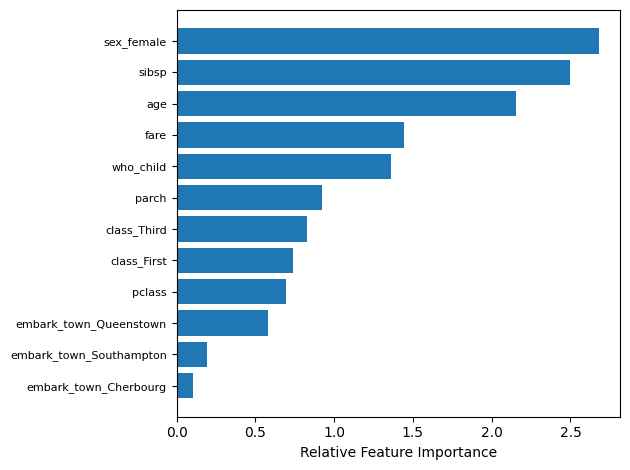

In [17]:
clf = LogisticRegression(penalty=None, random_state = 0,max_iter=50)
clf.fit(X_scaled, y)

feature_importance = abs(clf.coef_[0])
#feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure()
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, feature_importance[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(X.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()   
plt.show()

In [18]:
feature_importance[sorted_idx]

array([0.10387542, 0.19336503, 0.58010277, 0.69395716, 0.73818765,
       0.82946544, 0.92592052, 1.35855688, 1.44316138, 2.1553617 ,
       2.49890984, 2.68046906])

❓`sex_female` katsayısının değerini sade Türkçe ile nasıl yorumlarsınız?

<details>
    <summary>Cevap</summary>

> "Diğer tüm şeyler eşitken (yaş, bilet sınıfı vb...),
kadın olmak hayatta kalma log-oranlarınızı 2.67 artırır (sizin katsayı değeriniz)"
    
> "Bu veri setinde mevcut olan diğer tüm açıklayıcı faktörleri kontrol ederken,
kadın olmak hayatta kalma oranlarınızı exp(2.67) = 14 kat artırır"

</details>

In [20]:
X.columns[sorted_idx[-1]]

'sex_female'

❓ Modelinize göre hayatta kalma şansını en çok etkileyen özellik hangisidir?  
Aşağıdaki `top_1_feature` listesini bu özelliğin adıyla doldurun

In [21]:
top_1_feature = [X.columns[sorted_idx[-1]]]

In [35]:
from sklearn.svm import l1_min_c



In [22]:
from nbresult import ChallengeResult
result = ChallengeResult('unregularized', top_1_feature=top_1_feature)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/scorp08/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/scorp08/workintech_projeler/S16D5-S-regularization/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_unregularized.py::TestUnregularized::test_top_1 FAILED              [100%]

=================================== FAILURES ===================================
_________________________ TestUnregularized.test_top_1 _________________________

self = <tests.test_unregularized.TestUnregularized testMethod=test_top_1>

    def test_top_1(self):
        res_set = set(self.result.top_1_feature)
        minimal_truth_set = {"embark_town_Southampton", "embark_town_Queenstown", "embark_town_Cherbourg"}
>       self.assertTrue(len(res_set & minimal_truth_set) == 1, "Did you also check for negative coefficients?")
E       Ass

## 3. L2 cezalı Lojistik Regresyon

Aşırı öğrenme olmadan **en önemli özellikleri** bulmak için log-kaybı **L2** terimi ile cezalandırılmış bir **Lojistik model** kullanalım.  
Bu, "Ridge" regresörünün "sınıflandırma" karşılığıdır

❓ **Güçlü düzenlileştirilmiş** bir `LogisticRegression` oluşturun ve özelliklerini önem sırasına göre sıralayın (katsayılara bakın)
- "Güçlü düzenlileştirilmiş" ile "Sklearn'in varsayılan düzenlileştirme faktöründen daha fazla" demek istiyoruz. 
- Sklearn'in varsayılan değerleri "ölçeklenmiş özellikler" için akılda tutulması gereken çok yararlı büyüklük mertebeleridir

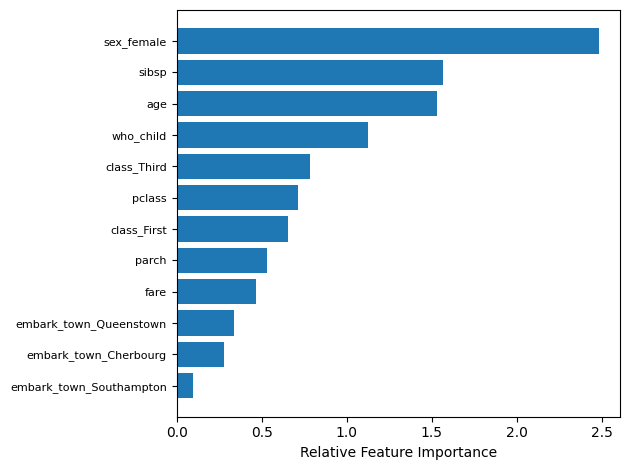

In [23]:
clf_2 = LogisticRegression(penalty="l2", random_state = 0,max_iter=50)
clf_2.fit(X_scaled, y)

feature_importance = abs(clf_2.coef_[0])
#feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure()
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, feature_importance[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(X.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()   
plt.show()

In [24]:
feature_importance[sorted_idx]

array([0.09767557, 0.27623026, 0.33799142, 0.46777442, 0.53218417,
       0.65646751, 0.71578171, 0.78632017, 1.12560138, 1.53184403,
       1.56404243, 2.48210985])

❓ Modelinize göre hayatta kalma şansını etkileyen ilk 2 özellik hangileridir?  
Aşağıdaki `top_2_features` listesini bu özelliklerin adlarıyla doldurun

In [52]:
top_2_features

['sex_female', 'class_Third']

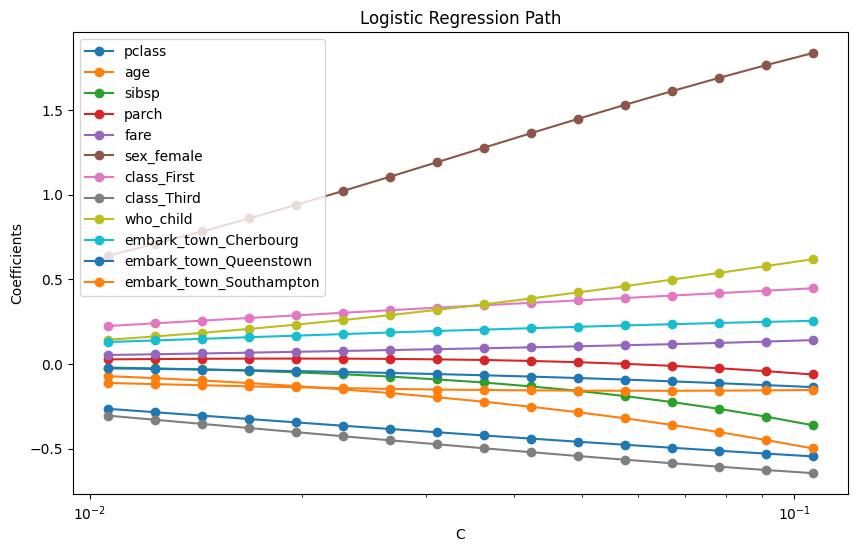

In [47]:
cs= l1_min_c(X_scaled, y, loss="log") * np.logspace(0, 1, 16)
coefs_ = []
for c in cs:
    clf_2.set_params(**{"C":c})
    clf_2.fit(X_scaled, y)
    coefs_.append(clf_2.coef_.ravel().copy())

coefs_ = np.array(coefs_)
colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100"]

plt.figure(figsize=(10, 6))
for i in range(coefs_.shape[1]):
    plt.semilogx(cs, coefs_[:, i], marker="o",  label=X_scaled.columns[i])

ymin, ymax = plt.ylim()
plt.xlabel("C")
plt.ylabel("Coefficients")
plt.title("Logistic Regression Path")
plt.legend()
plt.axis("tight")
plt.show()

In [49]:
coefs_[0]

array([-0.26465105, -0.07154029, -0.02098848,  0.02750208,  0.05302243,
        0.63982694,  0.22427951, -0.30505017,  0.14316938,  0.12980139,
       -0.02565351, -0.11202865])

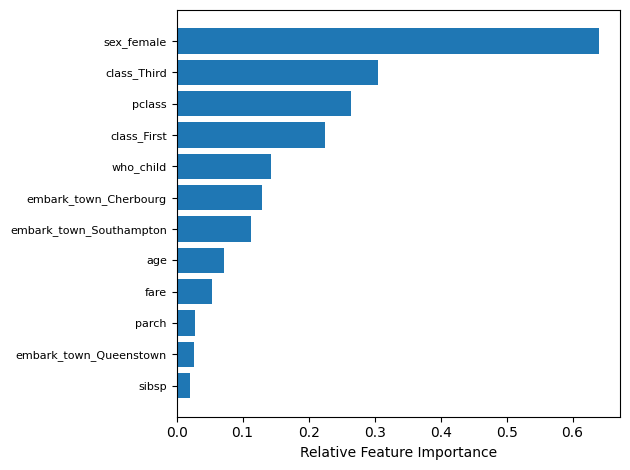

In [50]:
feature_importance = abs(coefs_[0])
#feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure()
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, feature_importance[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(X_scaled.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()   
plt.show()

In [53]:
top_2_features = [X.columns[sorted_idx[::-1][0]], X.columns[sorted_idx[::-1][1]]]

#### 🧪 Kodunuzu aşağıda test edin

In [54]:
from nbresult import ChallengeResult
result = ChallengeResult('ridge', top_2=top_2_features)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/scorp08/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/scorp08/workintech_projeler/S16D5-S-regularization/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_ridge.py::TestRidge::test_top2 PASSED                               [100%]

============================== 1 passed in 0.03s ===============================


💯 You can commit your code:

git add tests/ridge.pickle

git commit -m 'Completed ridge step'

git push origin master



## 4. L1 cezalı Lojistik Regresyon

Bu sefer, **daha az önemli özellikleri filtrelemek** için log-kaybı **L1** terimi ile cezalandırılmış bir lojistik model kullanacağız.  
Bu, **Lasso** regresörünün "sınıflandırma" karşılığıdır

❓ **Güçlü düzenlileştirilmiş** bir `LogisticRegression` oluşturun ve özelliklerini önem sırasına göre sıralayın

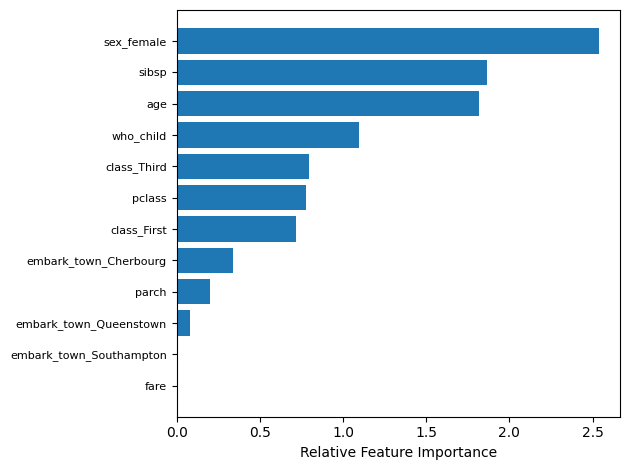

In [62]:
clf_3 = LogisticRegression(penalty="l1", random_state = 0, C=1, solver="saga")
clf_3.fit(X_scaled, y)

feature_importance = abs(clf_3.coef_[0])
#feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure()
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, feature_importance[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(X.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()   
plt.show()

In [66]:
coef_l1_LR = clf_3.coef_.ravel()
   
sparsity_l1_LR = np.mean(coef_l1_LR == 0) * 100


array([False, False, False, False,  True, False, False, False, False,
       False, False,  True])

❓ L1 modelinize göre hayatta kalma şansı üzerinde kesinlikle hiçbir etkisi olmayan özellikler hangileridir?  
Aşağıdaki `zero_impact_features` listesini bu özelliklerin adlarıyla doldurun; listeye eleman eklemeniz gerekebilir.

- Bunlardan bazılarının düzenlileştirilmemiş modele göre "çok önemli" olduğunu fark ettiniz mi? 
- Bundan sonra doğrusal modellerimizi her zaman düzenlileştireceğiz!

In [76]:
zero_impact_features = [X.columns[sorted_idx[0]], X.columns[sorted_idx[1]], X.columns[sorted_idx[2]], X.columns[sorted_idx[3]]]

In [77]:
zero_impact_features

['fare', 'embark_town_Southampton', 'embark_town_Queenstown', 'parch']

#### 🧪 Kodunuzu aşağıda test edin

In [78]:
from nbresult import ChallengeResult
result = ChallengeResult('lasso', zero_impact_features = zero_impact_features)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/scorp08/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/scorp08/workintech_projeler/S16D5-S-regularization/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_lasso.py::TestLasso::test_zero_impact PASSED                        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/lasso.pickle

git commit -m 'Completed lasso step'

git push origin master



# 5. Bir adım geri çekilmek

🤯 **Bu katsayılardan bazıları neden başlangıçta bu kadar yüksekti?**

Düzenlileştirme ile kaldırılan üç özelliği düşünelim:
- `embark_town_Cherbourg`
- `embark_town_Southampton`
- `embark_town_Queenstown`

Üç biniş şehri tabii ki ilişkilidir: ikisinden binmediyseniz, üçüncüsünden binmiş olmalısınız. Yani biliyoruz ki: 

$$embark\_town\_Cherbourg + embark\_town\_Southampton + embark\_town\_Queenstown = 1$$

Bu üç özellik **mükemmel çoklu doğrusal bağıntılıdır**!

**Düzenlileştirilmemiş modeller kullanılırken, bu genellikle sayısal kararsızlığa yol açar**, ki burada gördüğümüz tam olarak buydu. Ayrıca böyle bir durumda elde ettiğimiz **katsayılara gerçekten güvenemeyeceğimiz** anlamına gelir.

❗️ Bu üç çoklu doğrusal bağıntılı özellik, `embark_town` kategorik özelliğinin one hot encoding'inden gelir.

Düzenlileştirme sayesinde bu sorunu aştık: üç şehir için katsayıların çok büyük olmasını engelledi. **İşte bu yüzden neredeyse her zaman düzenlileştirme kullanacağız.**

🔍 **Başlangıçta ayarladığımız `tol` parametresini hatırlıyor musunuz?**

Düzenlileştirmenin ekstra bir bonusu da `tol` ayarlamanın daha az önemli hale gelmesi: `1e-2` ve `1e-9` arasında herhangi bir değere ayarlayabilirsiniz ve katsayılar neredeyse hiç değişmez! 💪

**🏁 Tebrikler! Not defterinizi commit etmeyi ve push etmeyi unutmayın**